# `kNNpy.kNN_3D.TracerTracerCross3D` Tutorial: Cross-clustering between two discrete tracer sets in a 3D simulation box using $k$-nearest neighbour distributions

**Author**: Subhankar Datta (subhankar.datta@students.iiserpune.ac.in)\
**Date**: 12 July 2026\
**kNNpy version**: 0.0.1

#### This notebook presents a simple guide on how to use the `kNNpy.kNN_3D.TracerTracerCross3D` module to compute the 3D cross-$k$NN distributions between two different sets of discrete tracers (Galaxies and Clusters) in a simulation box and interpret the results. The basic functionalities of the module are illustrated using realistic cosmological datasets from the [Quijote simulations](https://quijote-simulations.readthedocs.io/en/latest/). A detailed API [documentation](https://kitnenikatnivasi.github.io/kNNpy_documentation_html/kNNpy/kNN_3D.TracerTracerCross3D.html) and source code for the module is available on the `kNNpy` [website](https://kitnenikatnivasi.github.io/).

<!--TABLE OF CONTENTS-->
# Contents:
- [Imports and Setup](#Imports-and-Setup)
- [Cross-clustering of two discrete tracer sets](#Cross-clustering-of-two-discrete-tracer-sets)
    - [Load and prepare the data](#Load-and-prepare-the-data)
    - [Visualise the data](#Visualise-the-data)
    - [THINK: Why number densities must match](#-THINK:-Why-do-the-number-densities-for-both-the-cluster-and-the-galaxies-have-to-be-the-same?)
    - [Compute the relevant spatial scales](#Compute-the-relevant-spatial-scales)
    - [Construct the query points](#Construct-the-query-points)
- [Compute the cross-$k$NN-CDFs](#Compute-the-cross-k-NN-CDFs)
    - [Compute the excess cross-correlation](#Compute-the-excess-cross-correlation)
- [Interpretation of results](#Interpretation-of-results)
- [Excess Cross-Correlation with Errorbars](#Excess-Cross-Correlation-with-Errorbars)
- [Summary](#Summary)

# Imports and Setup

#### Let's start by importing the required Python libraries. These should already be present in the `kNNpy_env` virtual environment created during the [installation](https://kitnenikatnivasi.github.io/install.html), so you should be able to import them without any issues.

In [1]:
#Importing external libraries

import numpy as np
import pandas as pd

from matplotlib import pyplot as plt, ticker as mticker
import matplotlib.colors as colors

import copy

import os
import sys

import warnings

#We prefer turning off the annoying warnings thrown by Python. Comment out the line below if you prefer to view the warnings as they arise.
warnings.filterwarnings('ignore')

#Importing the kNNpy modules that will be used in this tutorial

#Necessary for relative imports (see https://stackoverflow.com/questions/34478398/import-local-function-from-a-module-housed-in-another-directory-with-relative-im)
module_path = os.path.abspath(os.path.join('../'))           # '../' is needed because the parent directory is one directories upstream of the tutorials directory
if module_path not in sys.path:
    sys.path.append(module_path)

from kNNpy import HelperFunctions as hf                 #some helper functions
from kNNpy import kNN_3D as k3D                            #the main module
from kNNpy.Data import Datasets                         #helpful for retreiving example datasets

In [2]:
#Matplotlib settings

plt.rcParams['font.family'] = 'serif'
plt.rc('text', usetex=True)
plt.rcParams.update({'font.size': 20})
plt.rcParams['xtick.labelsize'] = 18
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams["axes.linewidth"] = 2*0.8
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["xtick.major.width"] = 2*0.8
plt.rcParams["ytick.direction"] = 'in'
plt.rcParams["ytick.major.width"] = 2*0.8
plt.rcParams["xtick.major.size"] = 2*3.5
plt.rcParams["ytick.major.size"] = 2*3.5
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.width"] = 2*0.6
plt.rcParams["ytick.minor.width"] = 2*0.6
plt.rcParams["xtick.minor.size"] = 2*2
plt.rcParams["ytick.minor.size"] = 2*2

DefaultColorCycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
BrightColors = ['cyan', 'yellow', 'lime', 'pink', '#E0B0FF']

# Cross-clustering of two discrete tracer sets

#### In many astrophysical and cosmological contexts, it is important to quantify the spatial cross-correlation between two different types of objects — for example, galaxies and galaxy clusters, or dark matter particles and haloes. The $k$NN cross-correlation framework (Banerjee & Abel 2021) provides a powerful tool to quantify such cross-correlations.

#### The key idea is to compute:

1. $P_{\geq k_A}(r)$: the $k_A$NN-CDF of tracer set A
2. $P_{\geq k_B}(r)$: the $k_B$NN-CDF of tracer set B  
3. $P_{\geq k_A, \geq k_B}(r)$: the **joint** probability of finding at least $k_A$ tracers of set A **and** at least $k_B$ tracers of set B within a sphere of radius $r$

#### From these, the **excess cross-correlation** is:

$$\psi_{k_A, k_B}(r) = \frac{P_{\geq k_A, \geq k_B}(r)}{P_{\geq k_A}(r) \times P_{\geq k_B}(r)}$$

#### If the two tracer sets are uncorrelated, $\psi_{k_A, k_B} = 1$. Values $> 1$ indicate positive cross-correlation, while values $< 1$ indicate anti-correlation.

#### We will load pre-computed dark-matter halo catalogues (delineated into 'Galaxies' and 'Clusters' based on simple mass cuts) from the Quijote simulation boxes. These will serve as our two tracer sets.

## Load and prepare the data

#### We load the 3D halo catalogs of 'Galaxies' (mass $5 \times 10^{12} \leq M_h \leq 5 \times 10^{13} \, M_\odot/h$) and 'Clusters' (mass $10^{14} \leq M_h \leq 3.0 \times 10^{14} \, M_\odot/h$) directly from the local Quijote Rockstar files. The box size is 1000 Mpc/$h$.

In [3]:
#Simulation parameters
box_size = 1000.0  #Mpc/h
n_tracers_A = 9000  #number of Galaxy tracers
n_tracers_B = 9000   #number of Cluster tracers

#Set a random seed for sampling consistency
np.random.seed(42)

#Path to the Quijote simulations data directory
data_path = '../kNNpy/Data'

#Load Galaxies dataset (Tracer set A)
folder_ga = f'{data_path}/Quijote_simulations/Fiducial_HR_rockstar/Galaxy_cat'
ga_data = pd.read_csv(f'{folder_ga}/sim_000')
all_ga_pos = ga_data[['8', '9', '10']].values
TracerPos_A = all_ga_pos[np.random.choice(len(all_ga_pos), n_tracers_A, replace=False)]

#Load Clusters dataset (Tracer set B)
folder_cl = f'{data_path}/Quijote_simulations/Fiducial_HR_rockstar/Cluster_cat'
cl_data = pd.read_csv(f'{folder_cl}/sim_000')
all_cl_pos = cl_data[['8', '9', '10']].values
TracerPos_B = all_cl_pos[np.random.choice(len(all_cl_pos), n_tracers_B, replace=False)]

#Also generate a set of Poisson-distributed random tracers matching set B's density for comparison
randoms = Datasets.Sample3DPoissonTracers(1, n_tracers_B, boxsize=box_size)
RandomPos = np.mean(randoms, axis=0)

print('Tracer set A (Galaxies) shape:', TracerPos_A.shape)
print('Tracer set B (Clusters) shape:', TracerPos_B.shape)
print('Random tracer shape:', RandomPos.shape)

Tracer set A (Galaxies) shape: (9000, 3)
Tracer set B (Clusters) shape: (9000, 3)
Random tracer shape: (9000, 3)


In [4]:
# Print minimum and maximum mass, and total number of halos from both files
print('Galaxy catalog (sim_000):')
print(f'  Total number of halos: {len(ga_data)}')
print(f'  Min mass: {ga_data["2"].min():.4e} M_sun/h')
print(f'  Max mass: {ga_data["2"].max():.4e} M_sun/h')
print()
print('Cluster catalog (sim_000):')
print(f'  Total number of halos: {len(cl_data)}')
print(f'  Min mass: {cl_data["2"].min():.4e} M_sun/h')
print(f'  Max mass: {cl_data["2"].max():.4e} M_sun/h')


Galaxy catalog (sim_000):
  Total number of halos: 687906
  Min mass: 5.0063e+12 M_sun/h
  Max mass: 4.9981e+13 M_sun/h

Cluster catalog (sim_000):
  Total number of halos: 9640
  Min mass: 1.0004e+14 M_sun/h
  Max mass: 2.9988e+14 M_sun/h


## Visualise the data

#### Let's visualise how the Galaxies and Clusters are distributed in a slice of the simulation box by plotting a 2D projection:

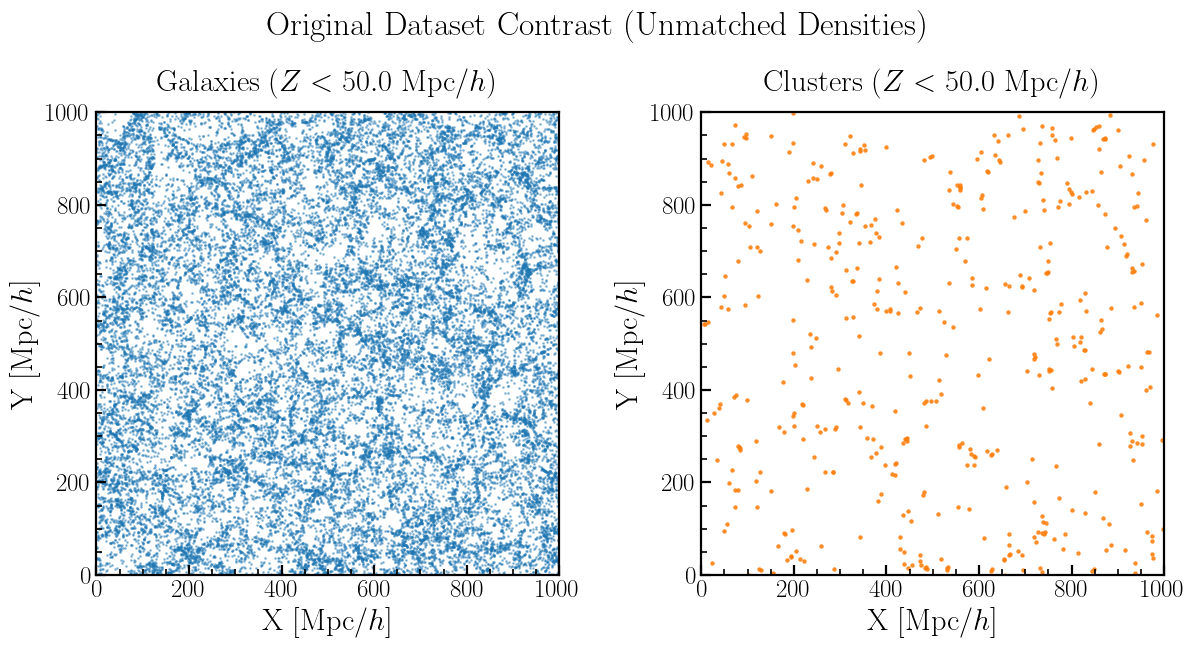

Total Galaxies in slice: 34400
Total Clusters in slice: 477


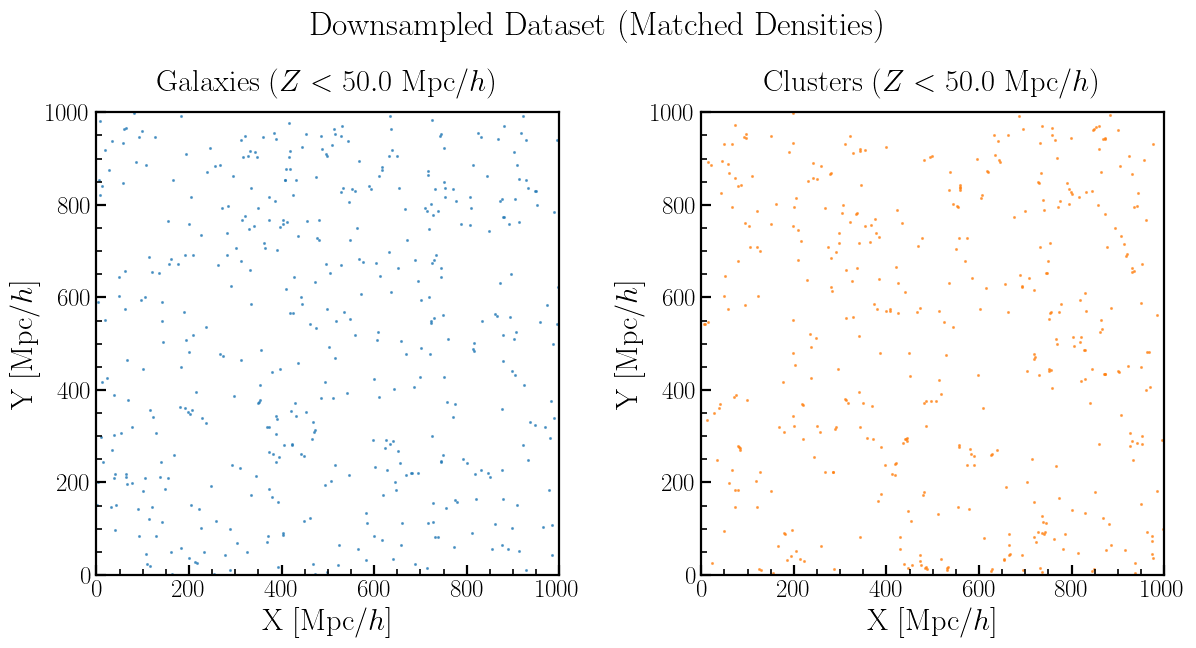

Downsampled Galaxies in slice: 464
Downsampled Clusters in slice: 445


In [5]:
# 1. Plot with all the data present to show the density difference
slice_thickness = 50.0
mask_full_A = all_ga_pos[:, 2] < slice_thickness
mask_full_B = all_cl_pos[:, 2] < slice_thickness

fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))

axes[0].set_title(f'Galaxies ($Z < {slice_thickness}$ Mpc/$h$)', pad=15, fontsize=22)
axes[0].set_xlabel('X [Mpc/$h$]', fontsize=22)
axes[0].set_ylabel('Y [Mpc/$h$]', fontsize=22)
axes[0].scatter(all_ga_pos[mask_full_A, 0], all_ga_pos[mask_full_A, 1], s=1.0, alpha=0.4, color=DefaultColorCycle[0])
axes[0].set_xlim(0, box_size)
axes[0].set_ylim(0, box_size)
axes[0].set_aspect('equal')

axes[1].set_title(f'Clusters ($Z < {slice_thickness}$ Mpc/$h$)', pad=15, fontsize=22)
axes[1].set_xlabel('X [Mpc/$h$]', fontsize=22)
axes[1].set_ylabel('Y [Mpc/$h$]', fontsize=22)
axes[1].scatter(all_cl_pos[mask_full_B, 0], all_cl_pos[mask_full_B, 1], s=5.0, alpha=0.8, color=DefaultColorCycle[1])
axes[1].set_xlim(0, box_size)
axes[1].set_ylim(0, box_size)
axes[1].set_aspect('equal')

plt.suptitle('Original Dataset Contrast (Unmatched Densities)', fontsize=24, y=0.98)
plt.tight_layout()
fig.subplots_adjust(wspace=0.15)
plt.show()

print(f"Total Galaxies in slice: {np.sum(mask_full_A)}")
print(f"Total Clusters in slice: {np.sum(mask_full_B)}")

# 2. Plot with downsampled data (matched densities)
mask_down_A = TracerPos_A[:, 2] < slice_thickness
mask_down_B = TracerPos_B[:, 2] < slice_thickness

fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))

axes[0].set_title(f'Galaxies ($Z < {slice_thickness}$ Mpc/$h$)', pad=15, fontsize=22)
axes[0].set_xlabel('X [Mpc/$h$]', fontsize=22)
axes[0].set_ylabel('Y [Mpc/$h$]', fontsize=22)
axes[0].scatter(TracerPos_A[mask_down_A, 0], TracerPos_A[mask_down_A, 1], s=1.5, alpha=0.6, color=DefaultColorCycle[0])
axes[0].set_xlim(0, box_size)
axes[0].set_ylim(0, box_size)
axes[0].set_aspect('equal')

axes[1].set_title(f'Clusters ($Z < {slice_thickness}$ Mpc/$h$)', pad=15, fontsize=22)
axes[1].set_xlabel('X [Mpc/$h$]', fontsize=22)
axes[1].set_ylabel('Y [Mpc/$h$]', fontsize=22)
axes[1].scatter(TracerPos_B[mask_down_B, 0], TracerPos_B[mask_down_B, 1], s=1.5, alpha=0.6, color=DefaultColorCycle[1])
axes[1].set_xlim(0, box_size)
axes[1].set_ylim(0, box_size)
axes[1].set_aspect('equal')

plt.suptitle('Downsampled Dataset (Matched Densities)', fontsize=24, y=0.98)
plt.tight_layout()
fig.subplots_adjust(wspace=0.15)
plt.show()

print(f"Downsampled Galaxies in slice: {np.sum(mask_down_A)}")
print(f"Downsampled Clusters in slice: {np.sum(mask_down_B)}")


## 💭 **THINK: Why do the number densities for both the cluster and the galaxies have to be the same?**

> Under a Poisson distribution, the typical physical scale of nearest-neighbour distances scales as $d \propto n^{-1/3}$. If the number densities of the two tracer populations are highly mismatched (e.g., $n_{\text{galaxy}} \gg n_{\text{cluster}}$):
> 1. **Premature Saturation**: The galaxy auto-CDF $P_{\ge k_A}(r)$ will saturate to $1.0$ at very small scales, where the cluster auto-CDF $P_{\ge k_B}(r)$ is still close to $0$.
> 2. **Loss of Cross-Correlation Information**: The joint CDF $P_{\ge k_A, \ge k_B}(r)$ will then simplify to the cluster auto-CDF $P_{\ge k_B}(r)$, driving the excess cross-correlation ratio $\psi(r)$ to $1.0$ (no correlation).
>
> By downsampling the denser tracer so that $n_A \approx n_B$, we align their characteristic physical scales, ensuring that the joint CDF is sensitive to the spatial cross-correlation between both populations rather than being dominated by the denser tracer.

## Compute the relevant spatial scales

#### To estimate the relevant spatial scales, we can use the expected $k$NN-CDFs for unclustered tracers with a given number density. For a Poisson-distributed set of tracers with number density $\bar{n}$, the analytical $k$NN-CDF can be computed using the in-built `PoissonUniformCDFs_3D()` helper function. This helps us identify the range of radial scales where the CDFs are sensitive (i.e., where they transition from 0 to 1).

Galaxy density: 9.000000e-06 (Mpc/h)^-3
Cluster density: 9.000000e-06 (Mpc/h)^-3


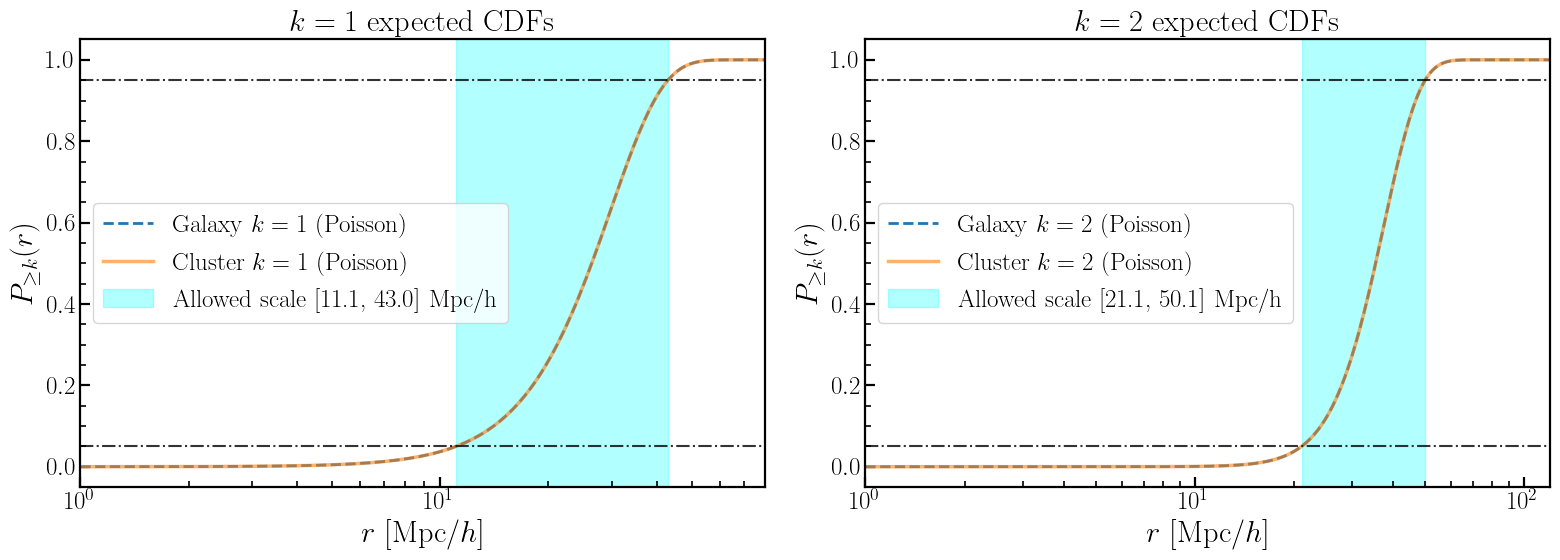

Selected radial scale for k=1 (Galaxy/Cluster): [11.08, 43.00] Mpc/h
Selected radial scale for k=2 (Galaxy/Cluster): [21.12, 50.11] Mpc/h


In [6]:
# Number densities of tracers
n_density_A = n_tracers_A / box_size**3
n_density_B = n_tracers_B / box_size**3
print(f'Galaxy density: {n_density_A:.6e} (Mpc/h)^-3')
print(f'Cluster density: {n_density_B:.6e} (Mpc/h)^-3')

# Radial scales to evaluate
r_eval = np.linspace(1.0, 120.0, 200)
v_eval = (4.0/3.0) * np.pi * r_eval**3  # volumes of spheres

# Compute Poisson CDFs for k=1, 2
k_values = [1, 2]
poisson_cdfs_A = {}
poisson_cdfs_B = {}
for k in k_values:
    poisson_cdfs_A[k] = hf.PoissonUniformCDFs_3D(v_eval, n_density_A, k)
    poisson_cdfs_B[k] = hf.PoissonUniformCDFs_3D(v_eval, n_density_B, k)

# Plot to find the relevant radial scales
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

selected_scales = {}

for i, k in enumerate(k_values):
    ax = axes[i]
    
    # Plot Galaxy and Cluster curves for the current k
    ax.plot(r_eval, poisson_cdfs_A[k], label=r'Galaxy $k={}$ (Poisson)'.format(k), color=DefaultColorCycle[0], lw=2.0, ls='--')
    ax.plot(r_eval, poisson_cdfs_B[k], label=r'Cluster $k={}$ (Poisson)'.format(k), color=DefaultColorCycle[1], lw=2.5, alpha=0.6)
    
    # Interpolate exact r values where CDF = 0.05 and 0.95 for Galaxy
    r_min_A = np.interp(0.05, poisson_cdfs_A[k], r_eval)
    r_max_A = np.interp(0.95, poisson_cdfs_A[k], r_eval)
    width_A = r_max_A - r_min_A
    
    # Interpolate exact r values where CDF = 0.05 and 0.95 for Cluster
    r_min_B = np.interp(0.05, poisson_cdfs_B[k], r_eval)
    r_max_B = np.interp(0.95, poisson_cdfs_B[k], r_eval)
    width_B = r_max_B - r_min_B
    
    # Select the curve with the smaller width (area)
    if width_A <= width_B:
        r_min, r_max = r_min_A, r_max_A
    else:
        r_min, r_max = r_min_B, r_max_B
        
    selected_scales[k] = (r_min, r_max)
    
    # Horizontal lines indicating 0.05 and 0.95 thresholds
    ax.axhline(y=0.05, color='black', ls='-.', lw=1.5, alpha=0.8)
    ax.axhline(y=0.95, color='black', ls='-.', lw=1.5, alpha=0.8)
    
    # Shade the span with the smaller area
    ax.axvspan(r_min, r_max, color='cyan', alpha=0.3, 
               label=f'Allowed scale [{r_min:.1f}, {r_max:.1f}] Mpc/h')
    
    ax.set_xlabel(r'$r$ [Mpc/$h$]', fontsize=22)
    ax.set_ylabel(r'$P_{\geq k}(r)$', fontsize=22)
    ax.set_title(r'$k={}$ expected CDFs'.format(k), fontsize=22)
    ax.legend(fontsize=18)
    ax.set_xscale('log')
    ax.set_xlim(1.0, 120.0 if k == 2 else 80.0)
    ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

# Store and print these radial scales
r_scale_k1 = selected_scales[1]
r_scale_k2 = selected_scales[2]

print(f"Selected radial scale for k=1 (Galaxy/Cluster): [{r_scale_k1[0]:.2f}, {r_scale_k1[1]:.2f}] Mpc/h")
print(f"Selected radial scale for k=2 (Galaxy/Cluster): [{r_scale_k2[0]:.2f}, {r_scale_k2[1]:.2f}] Mpc/h")


#### From the plots above, we can identify the radial scales where the CDFs transition from 0 to 1 — this is the range of scales where the $k$NN distributions are most informative. We will evaluate the cross-$k$NN-CDFs at these scales.

## Construct the query points

#### The next step is to construct the query points from which the nearest neighbour distances are to be computed. We will use the in-built `create_query_3D()` helper function to generate a uniform grid of query points:

In [7]:
#Create a grid of query points
query_grid = 30  #This gives 30^3 = 27000 query points
QueryPos = hf.create_query_3D('grid', query_grid, box_size)
print(f'Number of query points: {QueryPos.shape[0]}')
print(f'Query positions shape: {QueryPos.shape}')

Number of query points: 27000
Query positions shape: (27000, 3)


## Compute the cross-$k$NN-CDFs

#### Now we are ready to compute the cross-$k$NN-CDFs and measure the spatial cross-clustering between the Galaxies and Clusters!

#### The `TracerTracerCross3D()` method takes:
- `boxsize`: the simulation box size
- `kA_kB_list`: a list of $(k_A, k_B)$ tuples specifying which nearest-neighbour combinations to compute
- `BinsRad`: a list of radial distance arrays, one for each $(k_A, k_B)$ combination
- `QueryPos`: the query points
- `TracerPos_A`: positions of tracer set A
- `TracerPos_B`: positions of tracer set B

#### It returns three lists:
1. `p_gtr_kA_list`: the auto $k_A$NN-CDFs of tracer set A
2. `p_gtr_kB_list`: the auto $k_B$NN-CDFs of tracer set B
3. `p_gtr_kA_kB_list`: the **joint** $\{k_A, k_B\}$NN-CDFs

In [8]:
#Define the nearest-neighbour combinations
kA_kB_list = [(1, 1), (2, 2)]

#Define radial bins for each combination using the analytical scale limits
r_bins_k1 = np.linspace(r_scale_k1[0], r_scale_k1[1], 100)
r_bins_k2 = np.linspace(r_scale_k2[0], r_scale_k2[1], 100)
BinsRad = [r_bins_k1, r_bins_k2]

print(f'Number of kA-kB combinations: {len(kA_kB_list)}')
print(f'kA-kB combinations: {kA_kB_list}')
print(f'k=1 bin range: [{r_bins_k1[0]:.2f}, {r_bins_k1[-1]:.2f}] Mpc/h')
print(f'k=2 bin range: [{r_bins_k2[0]:.2f}, {r_bins_k2[-1]:.2f}] Mpc/h')


Number of kA-kB combinations: 2
kA-kB combinations: [(1, 1), (2, 2)]
k=1 bin range: [11.08, 43.00] Mpc/h
k=2 bin range: [21.12, 50.11] Mpc/h


In [9]:
#Compute the cross-kNN-CDFs between Galaxies and Clusters
p_gtr_kA_list, p_gtr_kB_list, p_gtr_kA_kB_list = k3D.TracerTracerCross3D(
    boxsize=box_size,
    kA_kB_list=kA_kB_list,
    BinsRad=BinsRad,
    QueryPos=QueryPos,
    TracerPos_A=TracerPos_A,
    TracerPos_B=TracerPos_B,
    n_threads=-1,
    Verbose=True
)

Checking inputs ...
	done.

building the trees ...
	first set of tracers done; time taken: 2.25e-03 s.
	second set of tracers done; time taken: 2.10e-03 s.
	combined time: 4.40e-03 s.

computing the tracer NN distances ...
	done; time taken: 1.21e-02 s.

computing the tracer auto-CDFs P_{>=kA}, P_{>=kB} ...
	done; time taken: 9.42e-03 s.

computing the joint-CDFs P_{>=kA, >=kB} ...
	done; time taken: 4.89e-03 s.

total time taken: 3.21e-02 s.


#### Now let's also compute the cross-$k$NN-CDFs between Galaxies and the **Poisson-distributed random tracers** — this will serve as a null test. For uncorrelated tracers, the joint CDF should equal the product of the individual auto CDFs, giving $\psi \approx 1$.

In [10]:
#Compute cross-kNN-CDFs between Galaxies and random tracers
p_gtr_kA_rand_list, p_gtr_kB_rand_list, p_gtr_kA_kB_rand_list = k3D.TracerTracerCross3D(
    boxsize=box_size,
    kA_kB_list=kA_kB_list,
    BinsRad=BinsRad,
    QueryPos=QueryPos,
    TracerPos_A=TracerPos_A,
    TracerPos_B=RandomPos,
    n_threads=-1,
    Verbose=True
)

Checking inputs ...
	done.

building the trees ...
	first set of tracers done; time taken: 2.16e-03 s.
	second set of tracers done; time taken: 2.03e-03 s.
	combined time: 4.23e-03 s.

computing the tracer NN distances ...
	done; time taken: 1.23e-02 s.

computing the tracer auto-CDFs P_{>=kA}, P_{>=kB} ...
	done; time taken: 9.11e-03 s.

computing the joint-CDFs P_{>=kA, >=kB} ...
	done; time taken: 4.82e-03 s.

total time taken: 3.16e-02 s.


## Compute the excess cross-correlation

#### The excess cross-correlation $\psi_{k_A, k_B}$ quantifies the departure of the joint CDF from statistical independence:

$$\psi_{k_A, k_B}(r) = \frac{P_{\geq k_A, \geq k_B}(r)}{P_{\geq k_A}(r) \times P_{\geq k_B}(r)}$$

#### We can compute this using the `kNN_excess_cross_corr()` helper function:

In [11]:
#Excess cross-correlation between Galaxies and Clusters
psi_AB = hf.kNN_excess_cross_corr(
    auto_cdf_list_1=p_gtr_kA_list,
    auto_cdf_list_2=p_gtr_kB_list,
    joint_cdf_list=p_gtr_kA_kB_list,
    k1_k2_list=kA_kB_list
)

#Excess cross-correlation between Galaxies and random tracers (null test)
psi_A_rand = hf.kNN_excess_cross_corr(
    auto_cdf_list_1=p_gtr_kA_rand_list,
    auto_cdf_list_2=p_gtr_kB_rand_list,
    joint_cdf_list=p_gtr_kA_kB_rand_list,
    k1_k2_list=kA_kB_list
)

print('Excess cross-correlation computed successfully!')

Excess cross-correlation computed successfully!


## Interpretation of results

#### Let's now visualise the results. We will plot:
1. The auto CDFs ($P_{\geq k_A}$, $P_{\geq k_B}$) and the joint CDF ($P_{\geq k_A, \geq k_B}$) for the Galaxy-Cluster cross-correlation
2. The excess cross-correlation $\psi_{k_A, k_B}$ as a function of the radial scale $r$
3. A comparison of the excess cross-correlation with the null case (Galaxies vs. random)

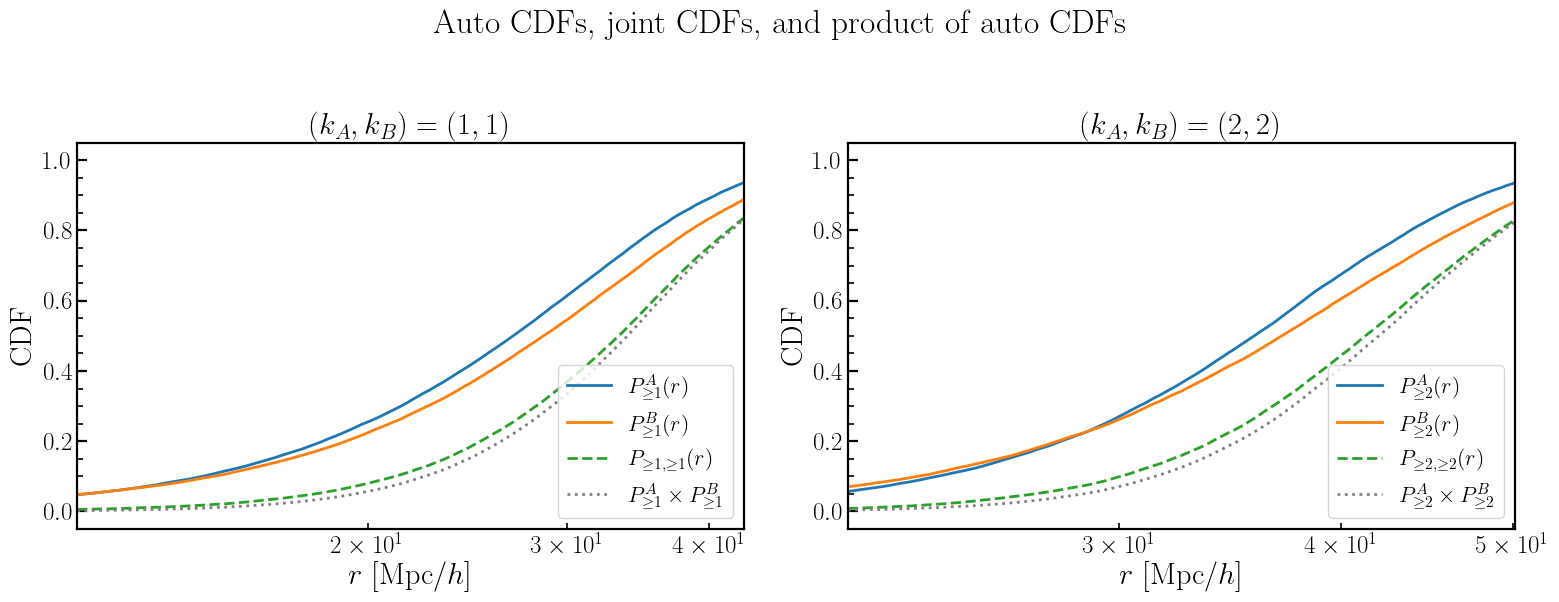

In [12]:
#Plot auto CDFs and joint CDFs
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx_c, (kA, kB) in enumerate(kA_kB_list):
    ax = axes[idx_c]
    r_bins_curr = BinsRad[idx_c]
    
    # Plot auto CDFs
    ax.plot(r_bins_curr, p_gtr_kA_list[idx_c], label=r'$P_{\geq %d}^{A}(r)$' % kA, lw=2, color=DefaultColorCycle[0])
    ax.plot(r_bins_curr, p_gtr_kB_list[idx_c], label=r'$P_{\geq %d}^{B}(r)$' % kB, lw=2, color=DefaultColorCycle[1])
    
    # Plot joint CDF
    ax.plot(r_bins_curr, p_gtr_kA_kB_list[idx_c], label=r'$P_{\geq %d, \geq %d}(r)$' % (kA, kB), 
             lw=2, color=DefaultColorCycle[2], ls='--')
             
    # Plot product of auto CDFs for reference
    product_cdf = p_gtr_kA_list[idx_c] * p_gtr_kB_list[idx_c]
    ax.plot(r_bins_curr, product_cdf, label=r'$P_{\geq %d}^A \times P_{\geq %d}^B$' % (kA, kB), 
            lw=2, color='gray', ls=':')
    
    ax.set_xlabel(r'$r$ [Mpc/$h$]', fontsize=22)
    ax.set_ylabel(r'CDF', fontsize=22)
    ax.set_title(r'$(k_A, k_B) = (%d, %d)$' % (kA, kB), fontsize=22)
    ax.legend(fontsize=16, loc='lower right')
    ax.set_xscale('log')
    ax.set_xlim(r_bins_curr[0], r_bins_curr[-1])
    ax.set_ylim(-0.05, 1.05)

plt.suptitle(r'Auto CDFs, joint CDFs, and product of auto CDFs', fontsize=24, y=1.02)
plt.tight_layout()
plt.show()


#### The key diagnostic is the **excess cross-correlation** $\psi_{k_A, k_B}(r)$. If the joint CDF exceeds the product of the auto CDFs, it means the Galaxies and Clusters are more clustered together than expected by chance.

#### Let's plot the excess cross-correlation for all $(k_A, k_B)$ combinations, comparing the Galaxy × Cluster case with the Galaxy × Random (null) case:

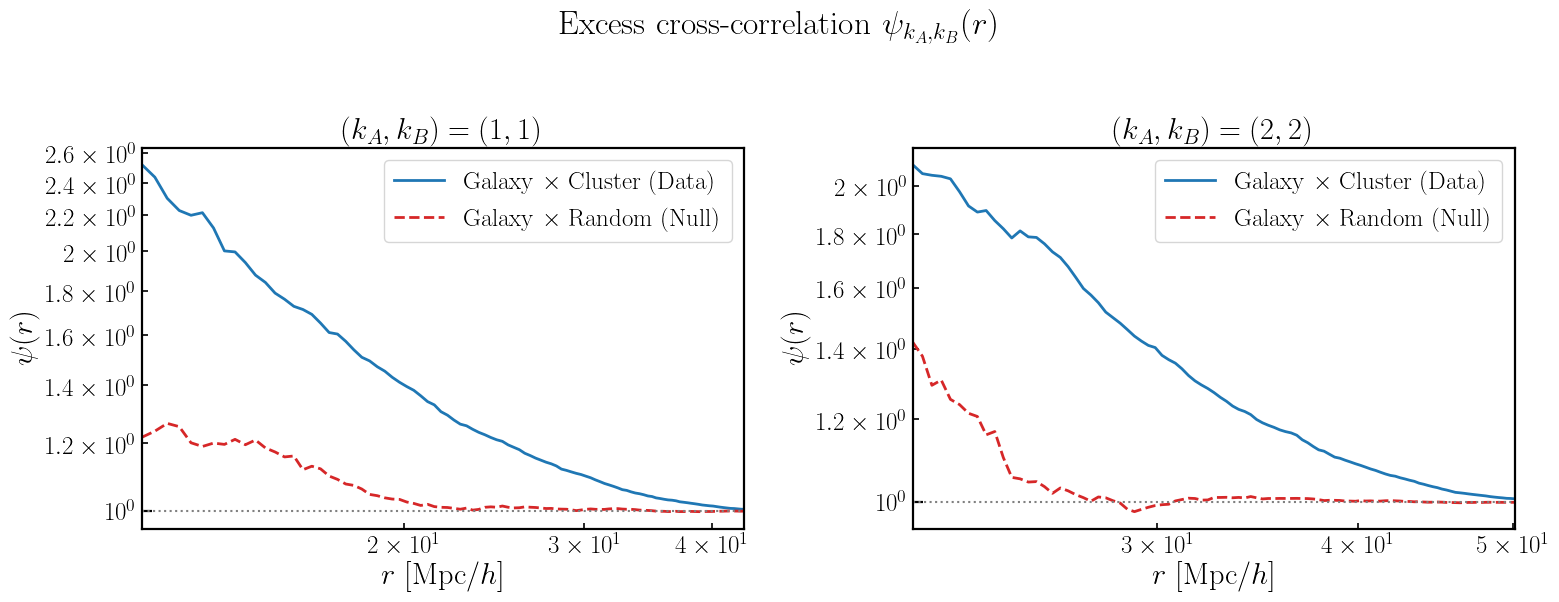

In [13]:
# Plotting the excess cross-correlation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx_c, (kA, kB) in enumerate(kA_kB_list):
    ax = axes[idx_c]
    r_bins_curr = BinsRad[idx_c]
    
    # Plot Galaxy x Cluster (Data)
    ax.plot(r_bins_curr, psi_AB[idx_c], lw=2, color=DefaultColorCycle[0], 
             label=r'Galaxy $\times$ Cluster (Data)')
    
    # Plot Galaxy x Random (Null)
    ax.plot(r_bins_curr, psi_A_rand[idx_c], lw=2, color=DefaultColorCycle[3], ls='--', 
             label=r'Galaxy $\times$ Random (Null)')
    
    ax.axhline(y=1.0, color='gray', ls=':', lw=1.5)
    
    ax.set_xlabel(r'$r$ [Mpc/$h$]', fontsize=22)
    ax.set_ylabel(r'$\psi(r)$', fontsize=22)
    ax.set_title(r'$(k_A, k_B) = (%d, %d)$' % (kA, kB), fontsize=22)
    ax.legend(fontsize=18)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(r_bins_curr[0], r_bins_curr[-1])

plt.suptitle(r'Excess cross-correlation $\psi_{k_A, k_B}(r)$', fontsize=24, y=1.02)
plt.tight_layout()
plt.show()


#### **Interpretation:**

- **Galaxy × Cluster (blue solid line):** Since both Galaxies and Clusters are loaded from the Quijote simulation box, they reside in the same cosmic web structure. Clusters represent highly massive overdensities where galaxies preferentially cluster. We therefore expect (and observe) a significant excess cross-correlation ($\psi > 1$), especially at smaller scales where clusters pull in surrounding galaxies.

- **Galaxy × Random (red dashed line):** The random tracers are drawn from a uniform Poisson distribution and have no spatial correlation with the Galaxies. The excess cross-correlation is therefore expected to be $\psi \approx 1$ at all scales, which serves as a null test for the method.

- At large scales, the excess cross-correlation approaches 1, as expected — large spheres encompass enough volume that the statistics approach those of a uniform distribution.

#### These results demonstrate the power of the $k$NN cross-correlation framework for detecting and quantifying spatial cross-correlations between two point sets, even when the signal might be weak or difficult to capture with traditional two-point correlation function approaches.

## Excess Cross-Correlation with Errorbars

#### To understand the statistical significance of the detected cross-clustering signal and the level of noise, we can compute the excess cross-correlation across multiple independent random samples (realizations) of Galaxies and Clusters. We will calculate the mean and $5 \times 1-\sigma$ errorbars over 100 realizations for both the actual data and the random control catalogs, focusing on the first nearest-neighbour combination $(k_A, k_B) = (1, 1)$.

In [34]:
# Number of realizations for errorbar calculation
n_realizations = 100
n_tracers_A = 9000
n_tracers_B = 9000

# Set up query points and radial bins (just kA=1, kB=1)
kA_kB_list_single = [(1, 1)]
BinsRad_single = [r_bins_k1]

print(f"Generating {n_realizations} realizations of Galaxies...")

# Load full datasets
fol_ga = f'{data_path}/Quijote_simulations/Fiducial_HR_rockstar/Galaxy_cat'
ga_data = pd.read_csv(f'{fol_ga}/sim_000')
all_ga_pos = ga_data[['8', '9', '10']].values

# Create a dictionary of Galaxy realizations (Tracer A)
pos_A_dict = {}
for i in range(n_realizations):
    np.random.seed(i + 100) # different seed per realization
    pos_A_dict[i] = all_ga_pos[np.random.choice(len(all_ga_pos), n_tracers_A, replace=False)]

# Keep Cluster (Tracer B) constant (using the original downsampled TracerPos_B)
print("Computing Galaxy x Cluster realizations (constant Cluster)...")
realizations_data = k3D.TracerTracerCross3D_DataVector(
    boxsize=box_size,
    kA_kB_list=kA_kB_list_single,
    BinsRad=BinsRad_single,
    QueryPos=QueryPos,
    TracerPos_A_dict=pos_A_dict,
    TracerPos_B=TracerPos_B,
    n_threads=-1,
    Verbose=False
)

# Keep Random (Tracer B) constant (using a single Poisson random catalog)
print("Computing Galaxy x Random realizations (constant Random)...")
pos_rand_constant = Datasets.Sample3DPoissonTracers(1, n_tracers_B, boxsize=box_size)[0]
realizations_rand = k3D.TracerTracerCross3D_DataVector(
    boxsize=box_size,
    kA_kB_list=kA_kB_list_single,
    BinsRad=BinsRad_single,
    QueryPos=QueryPos,
    TracerPos_A_dict=pos_A_dict,
    TracerPos_B=pos_rand_constant,
    n_threads=-1,
    Verbose=False
)

# Compute excess cross-correlations for all realizations
psi_data_list = []
psi_rand_list = []

for i in range(n_realizations):
    # realizations_data[i] is of shape (3, 1) containing [p_ga, p_cl, p_joint] lists/arrays
    psi_data = hf.kNN_excess_cross_corr(
        realizations_data[i, 0], 
        realizations_data[i, 1], 
        realizations_data[i, 2], 
        kA_kB_list_single
    )[0]
    psi_data_list.append(psi_data)
    
    psi_rand = hf.kNN_excess_cross_corr(
        realizations_rand[i, 0], 
        realizations_rand[i, 1], 
        realizations_rand[i, 2], 
        kA_kB_list_single
    )[0]
    psi_rand_list.append(psi_rand)

psi_data_arr = np.array(psi_data_list)
psi_rand_arr = np.array(psi_rand_list)

# Compute mean and standard deviations
mean_psi_data = np.mean(psi_data_arr, axis=0)
std_psi_data = np.std(psi_data_arr, axis=0)

mean_psi_rand = np.mean(psi_rand_arr, axis=0)
std_psi_rand = np.std(psi_rand_arr, axis=0)

print("Done!")


Generating 100 realizations of Galaxies...
Computing Galaxy x Cluster realizations (constant Cluster)...
Computing Galaxy x Random realizations (constant Random)...
Done!


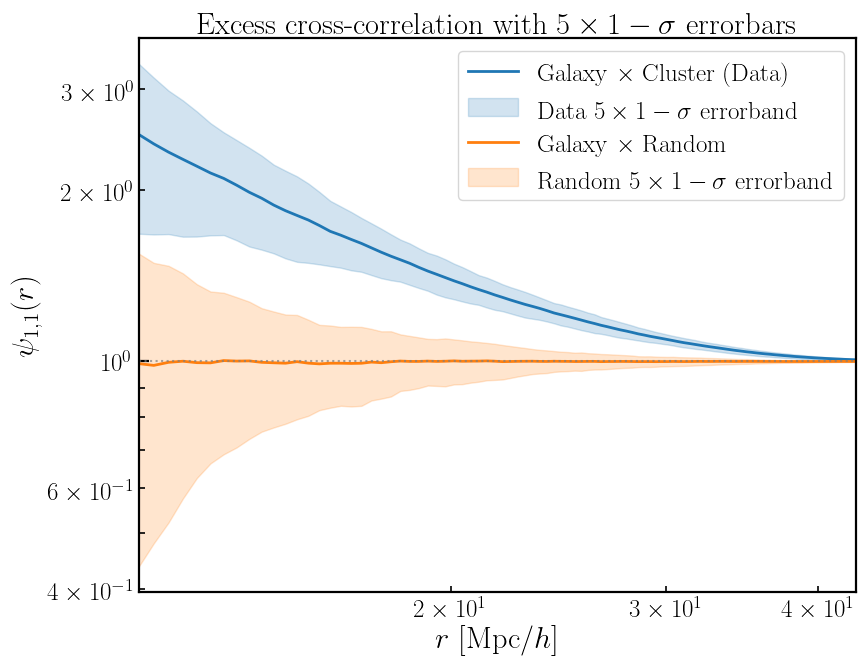

In [35]:
# Plot mean excess cross-correlation with 5x1-sigma error bars
plt.figure(figsize=(9, 7))

# Plot Data (Galaxy x Cluster)
plt.plot(r_bins_k1, mean_psi_data, label=r'Galaxy $\times$ Cluster (Data)', color=DefaultColorCycle[0], lw=2)
plt.fill_between(r_bins_k1, mean_psi_data - 5 * std_psi_data, mean_psi_data + 5 * std_psi_data, 
                 color=DefaultColorCycle[0], alpha=0.2, label=r'Data $5\times 1-\sigma$ errorband')

# Plot Random (Galaxy x Random)
plt.plot(r_bins_k1, mean_psi_rand, label=r'Galaxy $\times$ Random', color=DefaultColorCycle[1], lw=2)
plt.fill_between(r_bins_k1, mean_psi_rand - 5 * std_psi_rand, mean_psi_rand + 5 * std_psi_rand, 
                 color=DefaultColorCycle[1], alpha=0.2, label=r'Random $5\times 1-\sigma$ errorband')

# Reference line at psi = 1
plt.axhline(y=1.0, color='gray', ls=':', lw=1.5, alpha=0.7)

plt.xlabel(r'$r$ [Mpc/$h$]', fontsize=22)
plt.ylabel(r'$\psi_{1,1}(r)$', fontsize=22)
plt.title(r'Excess cross-correlation with $5\times 1-\sigma$ errorbars', fontsize=22)
plt.legend(fontsize=18)
plt.xscale('log')
plt.yscale('log')
plt.xlim(r_bins_k1[0], r_bins_k1[-1])

plt.tight_layout()
plt.show()

## Summary

In this tutorial, we have demonstrated how to use `kNNpy.kNN_3D.TracerTracerCross3D` to:

1. **Prepare two tracer sets (Galaxies and Clusters)** from cosmological Rockstar halo catalogs
2. **Set up the computation** by choosing appropriate $(k_A, k_B)$ combinations, radial bins, and query points
3. **Compute the cross-$k$NN-CDFs**: the auto CDFs $P_{\geq k_A}$, $P_{\geq k_B}$, and the joint CDF $P_{\geq k_A, \geq k_B}$
4. **Compute the excess cross-correlation** $\psi_{k_A, k_B}$ using the `kNN_excess_cross_corr()` helper function
5. **Interpret the results** and validate with a null test using random (Poisson) tracers

### Key points:
- The `TracerTracerCross3D` function handles the full computation, building KD-trees for both tracer sets, computing NN distances, evaluating auto and joint CDFs
- The excess cross-correlation $\psi = P_{\geq k_A, \geq k_B} / (P_{\geq k_A} \times P_{\geq k_B})$ directly quantifies the departure from statistical independence
- Higher-order $(k_A, k_B)$ combinations probe denser environments and can reveal complementary information about the cross-clustering
- When one tracer set is significantly denser than the other, consider using `TracerFieldCross3D()` instead, treating the denser set as a continuous field (see Gupta & Banerjee (2024) for details)

### References:
- Banerjee & Abel (2021): [Nearest neighbour distributions: New statistical measures for cosmological clustering](https://doi.org/10.1093/mnras/staa3604)
- Banerjee & Abel (2021): [Cosmological cross-correlations and nearest neighbour distributions](https://doi.org/10.1093/mnras/stab961)